# Анализ и визуализация результатов финального Fine-tuning на Benchmark-выборке: 4 стратегии и Scratch

### Импорты и базовые настройки

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

In [52]:
COLORS = {
    "scratch": "black",
    "partial_ft": "pink",
    "warmup": "purple",
    "full_ft": "blue",
    "low_lr_encoder": "red"
}

STRATEGY_RU = {
    "scratch": "Обучение с нуля",
    "full_ft": "Полный fine-tuning",
    "low_lr_encoder": "Замедленное дообучение энкодера",
    "partial_ft": "Частичный fine-tuning",
    "warmup": "Двухэтапное дообучение энкодера",
}

STRATEGY_ORDER = [
    "scratch",
    "full_ft",
    "low_lr_encoder",
    "partial_ft",
    "warmup",
]

### Пути

In [4]:
# === INPUT PATHS ===
ROOT = Path(r'C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\Fine-tuning_FULLSubjB')
FT_CSV = ROOT / 'FT_strategies_summary.csv'
SCRATCH_CSV = ROOT / 'Scratch_summary.csv'

# === OUTPUT DIRS ===
OUT_DIR = Path("analysis_outputs")
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FT_CSV exists:", FT_CSV.exists(), FT_CSV)
print("SCRATCH_CSV exists:", SCRATCH_CSV.exists(), SCRATCH_CSV)
print("Output dir:", OUT_DIR.resolve())

FT_CSV exists: True C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\Fine-tuning_FULLSubjB\FT_strategies_summary.csv
SCRATCH_CSV exists: True C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\Fine-tuning_FULLSubjB\Scratch_summary.csv
Output dir: C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\Fine-tuning_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\Fine-tuning_FULLSubjB\analysis_outputs


### Загрузка файлов

In [5]:
df_ft = pd.read_csv(FT_CSV)
df_scratch = pd.read_csv(SCRATCH_CSV)

print("df_ft shape:", df_ft.shape)
print("df_scratch shape:", df_scratch.shape)

display(df_ft.head())
display(df_scratch.head())

df_ft shape: (24, 28)
df_scratch shape: (6, 33)


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,warmup_epochs,selected_threshold,val_f1_at_selected_threshold,n_calib,n_val,n_test,n_pos_calib,n_pos_val,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr
0,subjB,bcicomp3,0,ssl_ft,full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.50,NaN,0,0,4564,0,0,760,NaN,NaN,NaN,0.509543,0.166521,0.2855,0.166521,1.0,0.001064
1,subjB,bcicomp3,0,ssl_ft,low_lr_encoder,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.50,NaN,0,0,4564,0,0,760,NaN,NaN,NaN,0.509543,0.166521,0.2855,0.166521,1.0,0.001064
2,subjB,bcicomp3,0,ssl_ft,partial_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.50,NaN,0,0,4564,0,0,760,NaN,NaN,NaN,0.509543,0.166521,0.2855,0.166521,1.0,0.001064
3,subjB,bcicomp3,0,ssl_ft,warmup,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,3.0,0.50,NaN,0,0,4564,0,0,760,NaN,NaN,NaN,0.509543,0.166521,0.2855,0.166521,1.0,0.001064
4,subjB,bcicomp3,10,ssl_ft,full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.05,0.282258,1064,213,4564,177,35,760,2.0,0.695601,12.0,0.497778,0.166521,0.2855,0.166521,1.0,0.000024


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,warmup_epochs,selected_threshold,val_f1_at_selected_threshold,n_calib,n_val,n_test,n_pos_calib,n_pos_val,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr,run_tag,history_path,predictions_path,status,error
0,subjB,bcicomp3,0,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.500,NaN,0,0,4564,0,0,760,NaN,NaN,NaN,0.482662,0.833479,0.000000,0.000000,0.000000,0.001954,bcicomp3__subjB__p0__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
1,subjB,bcicomp3,10,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.390,0.304348,1064,213,4564,177,35,760,5.0,0.680950,15.0,0.534771,0.375329,0.280958,0.173791,0.732895,0.006142,bcicomp3__subjB__p10__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
2,subjB,bcicomp3,20,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.050,0.285714,2130,426,4564,355,71,760,1.0,0.693578,11.0,0.538454,0.166521,0.285500,0.166521,1.000000,0.003930,bcicomp3__subjB__p20__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
3,subjB,bcicomp3,40,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.395,0.288840,4260,852,4564,710,142,760,1.0,0.696164,11.0,0.543721,0.248247,0.289207,0.171625,0.918421,0.008086,bcicomp3__subjB__p40__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
4,subjB,bcicomp3,60,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.375,0.300081,6390,1278,4564,1065,213,760,3.0,0.699812,13.0,0.548990,0.299080,0.287369,0.172969,0.848684,0.008091,bcicomp3__subjB__p60__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN


In [6]:
print("FT columns:")
print(df_ft.columns.tolist())

print("\nScratch columns:")
print(df_scratch.columns.tolist())

FT columns:
['subject_id', 'group', 'p', 'scenario', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr']

Scratch columns:
['subject_id', 'group', 'p', 'scenario', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr', 'run_tag', 'history_path', 'predictions_path', 'status', 'error']


### Приведение с единому формату и Объединение таблиц (только нужные признаки)

In [7]:
# --- копии ---
df_ft = df_ft.copy()
df_scratch = df_scratch.copy()

# --- создаём strategy ---
df_ft["strategy"] = df_ft["ft_strategy"].astype(str)
df_scratch["strategy"] = "scratch"

# --- приводим p ---
df_ft["p"] = df_ft["p"].astype(int)
df_scratch["p"] = df_scratch["p"].astype(int)

# --- оставляем только нужные колонки ---
core_cols = [
    "subject_id",
    "p",
    "strategy",
    "auc",
    "f1",
    "accuracy",
    "precision",
    "recall",
    "fdr"
]

optional_cols = ["group"]  # можно убрать, если не нужен

keep_cols = core_cols + optional_cols

df_ft = df_ft[keep_cols]
df_scratch = df_scratch[keep_cols]

# --- объединяем ---
df_all = pd.concat([df_ft, df_scratch], ignore_index=True)

print("df_all shape:", df_all.shape)
display(df_all.head())

df_all shape: (30, 10)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group
0,subjB,0,full_ft,0.509543,0.2855,0.166521,0.166521,1.0,0.001064,bcicomp3
1,subjB,0,low_lr_encoder,0.509543,0.2855,0.166521,0.166521,1.0,0.001064,bcicomp3
2,subjB,0,partial_ft,0.509543,0.2855,0.166521,0.166521,1.0,0.001064,bcicomp3
3,subjB,0,warmup,0.509543,0.2855,0.166521,0.166521,1.0,0.001064,bcicomp3
4,subjB,10,full_ft,0.497778,0.2855,0.166521,0.166521,1.0,0.000024,bcicomp3


#### Проверка базовых значений

In [8]:
print("Unique strategies:", sorted(df_all["strategy"].dropna().unique().tolist()))
print("Unique p:", sorted(df_all["p"].dropna().unique().tolist()))
print("Number of subjects:", df_all["subject_id"].nunique())

Unique strategies: ['full_ft', 'low_lr_encoder', 'partial_ft', 'scratch', 'warmup']
Unique p: [0, 10, 20, 40, 60, 100]
Number of subjects: 1


#### Проверка ключевых метрик и обязательных колонок

In [9]:
required_cols = [
    "subject_id", "p", "strategy",
    "auc", "f1", "accuracy", "precision", "recall", "fdr"
]

missing_required = [c for c in required_cols if c not in df_all.columns]
print("Missing required columns:", missing_required)

Missing required columns: []


#### Проверка дубликатов по ключу subject_id × p × strategy

In [10]:
key_cols = ["subject_id", "p", "strategy"]

dup_mask = df_all.duplicated(subset=key_cols, keep=False)
df_dups = df_all.loc[dup_mask].sort_values(key_cols)

print("Number of duplicated rows by key:", len(df_dups))
display(df_dups.head(20))

Number of duplicated rows by key: 0


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group


#### Проверка пропусков в метриках

In [11]:
metric_cols = ["auc", "f1", "accuracy", "precision", "recall", "fdr"]

na_report = df_all[metric_cols].isna().sum().sort_values(ascending=False)
print("NaN counts in metrics:")
display(na_report.to_frame("n_missing"))

NaN counts in metrics:


,n_missing
auc,0
f1,0
accuracy,0
precision,0
recall,0
fdr,0


In [12]:
# Проверка пропусков по стратегиям
na_by_strategy = df_all.groupby("strategy")[metric_cols].apply(lambda x: x.isna().sum())
display(na_by_strategy)

,auc,f1,accuracy,precision,recall,fdr
strategy,,,,,,
full_ft,0,0,0,0,0,0
low_lr_encoder,0,0,0,0,0,0
partial_ft,0,0,0,0,0,0
scratch,0,0,0,0,0,0
warmup,0,0,0,0,0,0


#### Проверка числа наблюдений по стратегиям и по p

In [13]:
count_by_strategy_p = (
    df_all.groupby(["strategy", "p"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

display(count_by_strategy_p)

p,0,10,20,40,60,100
strategy,,,,,,
full_ft,1,1,1,1,1,1
low_lr_encoder,1,1,1,1,1,1
partial_ft,1,1,1,1,1,1
scratch,1,1,1,1,1,1
warmup,1,1,1,1,1,1


#### Проверка парности по субъектам

In [14]:
subjects_by_strategy_p = (
    df_all.groupby(["strategy", "p"])["subject_id"]
    .apply(lambda s: set(s.tolist()))
)

all_strategies = sorted(df_all["strategy"].unique())
all_p = sorted(df_all["p"].unique())

pairing_report = []

for p in all_p:
    base_subjects = subjects_by_strategy_p.get(("scratch", p), set())
    for strategy in all_strategies:
        cur_subjects = subjects_by_strategy_p.get((strategy, p), set())
        pairing_report.append({
            "p": p,
            "strategy": strategy,
            "n_subjects": len(cur_subjects),
            "same_as_scratch": cur_subjects == base_subjects,
            "missing_vs_scratch": len(base_subjects - cur_subjects),
            "extra_vs_scratch": len(cur_subjects - base_subjects),
        })

pairing_report_df = pd.DataFrame(pairing_report).sort_values(["p", "strategy"])
display(pairing_report_df)

,p,strategy,n_subjects,same_as_scratch,missing_vs_scratch,extra_vs_scratch
0,0,full_ft,1,True,0,0
1,0,low_lr_encoder,1,True,0,0
2,0,partial_ft,1,True,0,0
3,0,scratch,1,True,0,0
4,0,warmup,1,True,0,0
5,10,full_ft,1,True,0,0
6,10,low_lr_encoder,1,True,0,0
7,10,partial_ft,1,True,0,0
8,10,scratch,1,True,0,0
9,10,warmup,1,True,0,0


### Сохраняем промежуточную объединённую таблицу

In [ ]:
# df_all.to_csv(TAB_DIR / "combined_all_results.csv", index=False)
# pairing_report_df.to_csv(TAB_DIR / "pairing_report.csv", index=False)
# count_by_strategy_p.to_csv(TAB_DIR / "count_by_strategy_p.csv")

### Короткий автоматический sanity-check

In [16]:
expected_strategies = {"scratch", "full_ft", "low_lr_encoder", "partial_ft", "warmup"}
expected_p = {0, 10, 20, 40, 60, 100}

actual_strategies = set(df_all["strategy"].dropna().unique())
actual_p = set(df_all["p"].dropna().unique())

print("Strategies OK:", actual_strategies == expected_strategies)
print("p values OK:", actual_p == expected_p)
print("No duplicate keys:", len(df_dups) == 0)
print("No missing metrics:", df_all[metric_cols].isna().sum().sum() == 0)

Strategies OK: True
p values OK: True
No duplicate keys: True
No missing metrics: True


## Формирование финальной аналитической таблицы

#### Базовая агрегация

In [17]:
metric_cols = ["auc", "f1", "accuracy", "precision", "recall", "fdr"]

summary = (
    df_all
    .groupby(["strategy", "p"])[metric_cols]
    .agg(["mean", "std", "median"])
)

# flatten columns
summary.columns = ["_".join(col) for col in summary.columns]

# добавим число субъектов
n_subjects = (
    df_all
    .groupby(["strategy", "p"])["subject_id"]
    .nunique()
    .rename("n_subjects")
)

summary = summary.join(n_subjects)

summary = summary.reset_index()

display(summary.head())

,strategy,p,auc_mean,auc_std,auc_median,f1_mean,f1_std,f1_median,accuracy_mean,accuracy_std,accuracy_median,precision_mean,precision_std,precision_median,recall_mean,recall_std,recall_median,fdr_mean,fdr_std,fdr_median,n_subjects
0,full_ft,0,0.509543,NaN,0.509543,0.285500,NaN,0.285500,0.166521,NaN,0.166521,0.166521,NaN,0.166521,1.000000,NaN,1.000000,0.001064,NaN,0.001064,1
1,full_ft,10,0.497778,NaN,0.497778,0.285500,NaN,0.285500,0.166521,NaN,0.166521,0.166521,NaN,0.166521,1.000000,NaN,1.000000,0.000024,NaN,0.000024,1
2,full_ft,20,0.538968,NaN,0.538968,0.286745,NaN,0.286745,0.177038,NaN,0.177038,0.167554,NaN,0.167554,0.993421,NaN,0.993421,0.011606,NaN,0.011606,1
3,full_ft,40,0.514269,NaN,0.514269,0.285230,NaN,0.285230,0.167616,NaN,0.167616,0.166411,NaN,0.166411,0.997368,NaN,0.997368,0.004854,NaN,0.004854,1
4,full_ft,60,0.612573,NaN,0.612573,0.296218,NaN,0.296218,0.270158,NaN,0.270158,0.176441,NaN,0.176441,0.922368,NaN,0.922368,0.083903,NaN,0.083903,1


#### Отдельная таблица mean ± std

In [18]:
def mean_std_str(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

table_mean_std = summary.copy()

for m in ["auc", "f1", "accuracy"]:
    table_mean_std[f"{m}_mean_std"] = table_mean_std.apply(
        lambda row: mean_std_str(row[f"{m}_mean"], row[f"{m}_std"]),
        axis=1
    )

cols_for_table = [
    "strategy", "p", "n_subjects",
    "auc_mean_std",
    "f1_mean_std",
    "accuracy_mean_std"
]

table_mean_std = table_mean_std[cols_for_table]

display(table_mean_std)

,strategy,p,n_subjects,auc_mean_std,f1_mean_std,accuracy_mean_std
0,full_ft,0,1,0.5095 ± nan,0.2855 ± nan,0.1665 ± nan
1,full_ft,10,1,0.4978 ± nan,0.2855 ± nan,0.1665 ± nan
2,full_ft,20,1,0.5390 ± nan,0.2867 ± nan,0.1770 ± nan
3,full_ft,40,1,0.5143 ± nan,0.2852 ± nan,0.1676 ± nan
4,full_ft,60,1,0.6126 ± nan,0.2962 ± nan,0.2702 ± nan
5,full_ft,100,1,0.7441 ± nan,0.3683 ± nan,0.5234 ± nan
6,low_lr_encoder,0,1,0.5095 ± nan,0.2855 ± nan,0.1665 ± nan
7,low_lr_encoder,10,1,0.4993 ± nan,0.2855 ± nan,0.1665 ± nan
8,low_lr_encoder,20,1,0.5251 ± nan,0.2856 ± nan,0.1667 ± nan
9,low_lr_encoder,40,1,0.5112 ± nan,0.2855 ± nan,0.1665 ± nan


#### Pivot-таблица

In [19]:
pivot_auc = table_mean_std.pivot(index="p", columns="strategy", values="auc_mean_std")
pivot_f1 = table_mean_std.pivot(index="p", columns="strategy", values="f1_mean_std")
pivot_acc = table_mean_std.pivot(index="p", columns="strategy", values="accuracy_mean_std")

print("AUC:")
display(pivot_auc)

print("\nF1:")
display(pivot_f1)

print("\nAccuracy:")
display(pivot_acc)

AUC:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.5095 ± nan,0.5095 ± nan,0.5095 ± nan,0.4827 ± nan,0.5095 ± nan
10,0.4978 ± nan,0.4993 ± nan,0.5051 ± nan,0.5348 ± nan,0.4983 ± nan
20,0.5390 ± nan,0.5251 ± nan,0.5244 ± nan,0.5385 ± nan,0.5270 ± nan
40,0.5143 ± nan,0.5112 ± nan,0.5087 ± nan,0.5437 ± nan,0.5347 ± nan
60,0.6126 ± nan,0.5482 ± nan,0.5735 ± nan,0.5490 ± nan,0.5555 ± nan
100,0.7441 ± nan,0.5538 ± nan,0.5793 ± nan,0.5610 ± nan,0.5649 ± nan



F1:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.2855 ± nan,0.2855 ± nan,0.2855 ± nan,0.0000 ± nan,0.2855 ± nan
10,0.2855 ± nan,0.2855 ± nan,0.2857 ± nan,0.2810 ± nan,0.2819 ± nan
20,0.2867 ± nan,0.2856 ± nan,0.2855 ± nan,0.2855 ± nan,0.2860 ± nan
40,0.2852 ± nan,0.2855 ± nan,0.2855 ± nan,0.2892 ± nan,0.2855 ± nan
60,0.2962 ± nan,0.2863 ± nan,0.2922 ± nan,0.2874 ± nan,0.2863 ± nan
100,0.3683 ± nan,0.2853 ± nan,0.2914 ± nan,0.2862 ± nan,0.2889 ± nan



Accuracy:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.1665 ± nan,0.1665 ± nan,0.1665 ± nan,0.8335 ± nan,0.1665 ± nan
10,0.1665 ± nan,0.1665 ± nan,0.1674 ± nan,0.3753 ± nan,0.2320 ± nan
20,0.1770 ± nan,0.1667 ± nan,0.1665 ± nan,0.1665 ± nan,0.1696 ± nan
40,0.1676 ± nan,0.1665 ± nan,0.1665 ± nan,0.2482 ± nan,0.1665 ± nan
60,0.2702 ± nan,0.1981 ± nan,0.2421 ± nan,0.2991 ± nan,0.1805 ± nan
100,0.5234 ± nan,0.1678 ± nan,0.2382 ± nan,0.1716 ± nan,0.3236 ± nan


#### Сохраняем таблицы

In [ ]:
# summary.to_csv(TAB_DIR / "summary_full_stats.csv", index=False)
# table_mean_std.to_csv(TAB_DIR / "summary_mean_std.csv", index=False)
# #
# pivot_auc.to_csv(TAB_DIR / "pivot_auc.csv")
# pivot_f1.to_csv(TAB_DIR / "pivot_f1.csv")
# pivot_acc.to_csv(TAB_DIR / "pivot_accuracy.csv")

## Основные графики

- ROC-AUC vs p
- F1 vs p
- Accuracy vs p

#### Подготовка данных для графиков

In [21]:
plot_df = (
    df_all
    .groupby(["strategy", "p"])[["auc", "f1", "accuracy"]]
    .agg(["mean", "std"])
)

plot_df.columns = ["_".join(col) for col in plot_df.columns]
plot_df = plot_df.reset_index()

display(plot_df.head())

,strategy,p,auc_mean,auc_std,f1_mean,f1_std,accuracy_mean,accuracy_std
0,full_ft,0,0.509543,NaN,0.285500,NaN,0.166521,NaN
1,full_ft,10,0.497778,NaN,0.285500,NaN,0.166521,NaN
2,full_ft,20,0.538968,NaN,0.286745,NaN,0.177038,NaN
3,full_ft,40,0.514269,NaN,0.285230,NaN,0.167616,NaN
4,full_ft,60,0.612573,NaN,0.296218,NaN,0.270158,NaN


#### Функция для построения графика

In [36]:
def make_strategy_label(row):
    scenario = row.get("scenario", None)
    ft_strategy = row.get("ft_strategy", None)

    if scenario == "scratch":
        return "С нуля"
    if pd.notna(ft_strategy):
        return STRATEGY_RU.get(ft_strategy, str(ft_strategy))
    return str(scenario)

In [51]:
def draw_metric_plot(metric, ylabel):
    plt.figure(figsize=(7, 5))

    p_values = [0, 10, 20, 40, 60, 100]

    strategies_present = [
        s for s in STRATEGY_ORDER
        if s in plot_df["strategy"].unique()
    ]

    for strategy in strategies_present:
        sub = plot_df[plot_df["strategy"] == strategy].copy()
        sub = sub.set_index("p").loc[p_values].reset_index()

        x = sub["p"]
        y = sub[f"{metric}_mean"]
        yerr = sub[f"{metric}_std"]

        linestyle = "--" if strategy == "scratch" else "-"

        plt.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            color=COLORS[strategy],
            label=STRATEGY_RU.get(strategy, strategy),
        )

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

    plt.xticks(p_values)
    plt.xlabel("Объём калибровки p (%)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} в зависимости от объёма калибровки")
    plt.legend(title="Стратегия")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

#### Строим графики

In [53]:
def plot_metric(metric, ylabel):
    draw_metric_plot(metric, ylabel)
    plt.show()

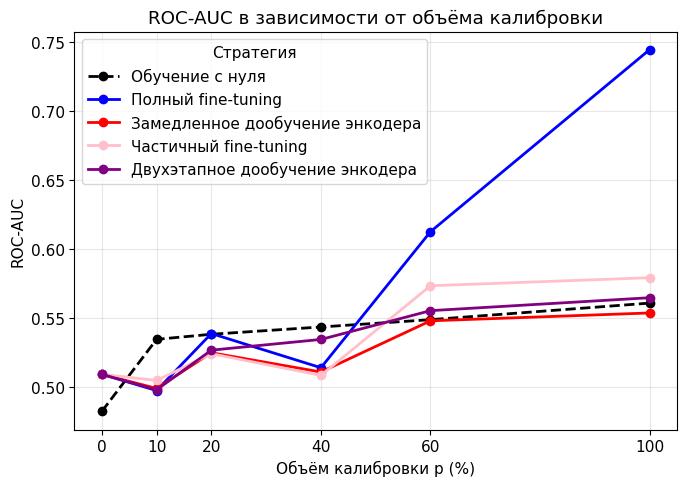

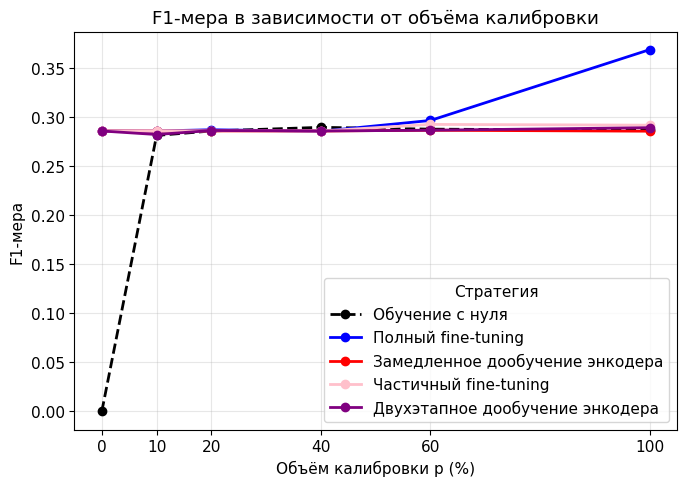

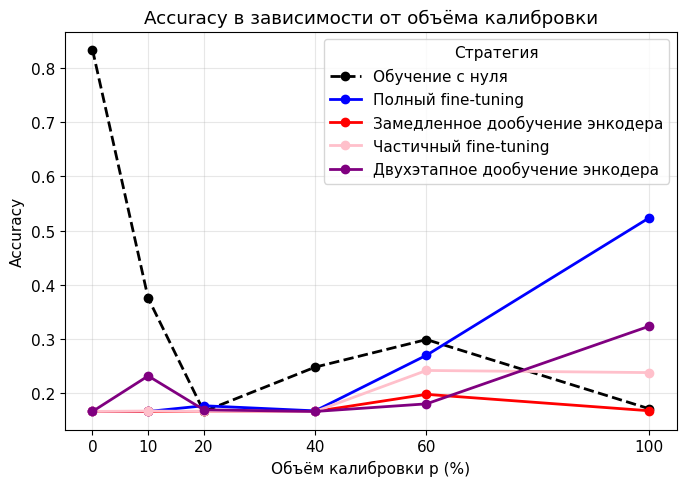

In [54]:
plot_metric("auc", "ROC-AUC")
plot_metric("f1", "F1-мера")
plot_metric("accuracy", "Accuracy")

#### Сохраняем графики

In [55]:
def save_plot(metric, ylabel, filename):
    draw_metric_plot(metric, ylabel)

    save_path = FIG_DIR / filename
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.savefig(save_path.with_suffix(".pdf"))
    plt.close()

    print(f"Сохранено: {save_path}")

In [57]:
save_plot("auc", "ROC-AUC", "auc_vs_p.png")
save_plot("f1", "F1-мера", "f1_vs_p.png")
save_plot("accuracy", "Accuracy", "accuracy_vs_p.png")

Сохранено: analysis_outputs\figures\auc_vs_p.png
Сохранено: analysis_outputs\figures\f1_vs_p.png
Сохранено: analysis_outputs\figures\accuracy_vs_p.png


## Графики выигрыша относительно scratch

#### per-subject delta

In [29]:
metric_cols = ["auc", "f1", "accuracy"]

# scratch как база
df_scratch_base = (
    df_all[df_all["strategy"] == "scratch"]
    [["subject_id", "p"] + metric_cols]
    .rename(columns={m: f"{m}_scratch" for m in metric_cols})
    .copy()
)

# все не-scratch стратегии
df_non_scratch = df_all[df_all["strategy"] != "scratch"].copy()

# merge по subject_id и p
df_delta = df_non_scratch.merge(
    df_scratch_base,
    on=["subject_id", "p"],
    how="inner"
)

# считаем дельты
for m in metric_cols:
    df_delta[f"delta_{m}"] = df_delta[m] - df_delta[f"{m}_scratch"]

print("df_delta shape:", df_delta.shape)
display(df_delta.head())

df_delta shape: (24, 16)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group,auc_scratch,f1_scratch,accuracy_scratch,delta_auc,delta_f1,delta_accuracy
0,subjB,0,full_ft,0.509543,0.2855,0.166521,0.166521,1.0,0.001064,bcicomp3,0.482662,0.000000,0.833479,0.026882,0.285500,-0.666959
1,subjB,0,low_lr_encoder,0.509543,0.2855,0.166521,0.166521,1.0,0.001064,bcicomp3,0.482662,0.000000,0.833479,0.026882,0.285500,-0.666959
2,subjB,0,partial_ft,0.509543,0.2855,0.166521,0.166521,1.0,0.001064,bcicomp3,0.482662,0.000000,0.833479,0.026882,0.285500,-0.666959
3,subjB,0,warmup,0.509543,0.2855,0.166521,0.166521,1.0,0.001064,bcicomp3,0.482662,0.000000,0.833479,0.026882,0.285500,-0.666959
4,subjB,10,full_ft,0.497778,0.2855,0.166521,0.166521,1.0,0.000024,bcicomp3,0.534771,0.280958,0.375329,-0.036993,0.004541,-0.208808


In [30]:
check_delta = (
    df_delta.groupby(["strategy", "p"])[["delta_auc", "delta_f1", "delta_accuracy"]]
    .agg(["mean", "std", "median"])
)

check_delta.columns = ["_".join(col) for col in check_delta.columns]
check_delta = check_delta.reset_index()

display(check_delta)

,strategy,p,delta_auc_mean,delta_auc_std,delta_auc_median,delta_f1_mean,delta_f1_std,delta_f1_median,delta_accuracy_mean,delta_accuracy_std,delta_accuracy_median
0,full_ft,0,0.026882,NaN,0.026882,0.285500,NaN,0.285500,-0.666959,NaN,-0.666959
1,full_ft,10,-0.036993,NaN,-0.036993,0.004541,NaN,0.004541,-0.208808,NaN,-0.208808
2,full_ft,20,0.000514,NaN,0.000514,0.001246,NaN,0.001246,0.010517,NaN,0.010517
3,full_ft,40,-0.029452,NaN,-0.029452,-0.003976,NaN,-0.003976,-0.080631,NaN,-0.080631
4,full_ft,60,0.063583,NaN,0.063583,0.008849,NaN,0.008849,-0.028922,NaN,-0.028922
5,full_ft,100,0.183144,NaN,0.183144,0.082084,NaN,0.082084,0.351884,NaN,0.351884
6,low_lr_encoder,0,0.026882,NaN,0.026882,0.285500,NaN,0.285500,-0.666959,NaN,-0.666959
7,low_lr_encoder,10,-0.035462,NaN,-0.035462,0.004541,NaN,0.004541,-0.208808,NaN,-0.208808
8,low_lr_encoder,20,-0.013354,NaN,-0.013354,0.000054,NaN,0.000054,0.000219,NaN,0.000219
9,low_lr_encoder,40,-0.032554,NaN,-0.032554,-0.003707,NaN,-0.003707,-0.081727,NaN,-0.081727


#### Функция для delta-графика

In [31]:
def plot_delta_metric(delta_metric, ylabel):
    plt.figure(figsize=(8, 5))

    p_values = [0, 10, 20, 40, 60, 100]
    strategies = sorted(df_delta["strategy"].unique())

    for strategy in strategies:
        sub = (
            df_delta[df_delta["strategy"] == strategy]
            .groupby("p")[delta_metric]
            .agg(["mean", "std"])
            .reset_index()
            .set_index("p")
            .loc[p_values]
            .reset_index()
        )

        x = sub["p"]
        y = sub["mean"]
        yerr = sub["std"]

        plt.plot(x, y, marker="o", label=strategy, color=COLORS[strategy])
        plt.fill_between(x, y - yerr, y + yerr, alpha=0.15, color=COLORS[strategy])

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks(p_values)
    plt.xlabel("Calibration size p (%)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} relative to Scratch")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Строим Δ-графики

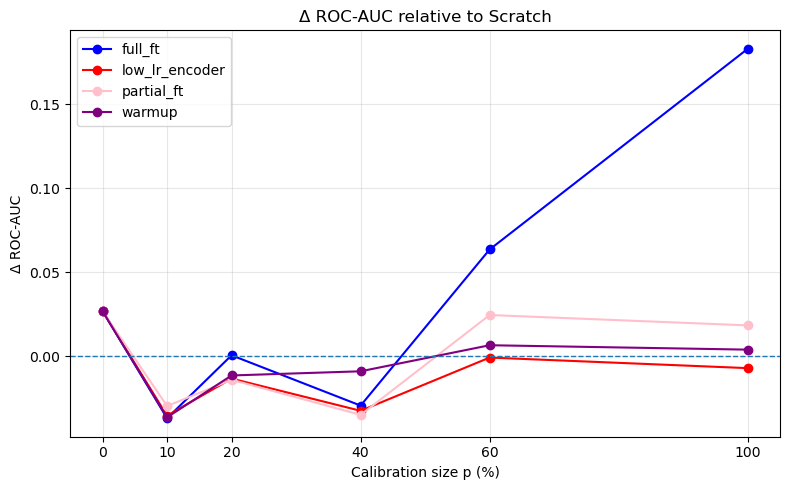

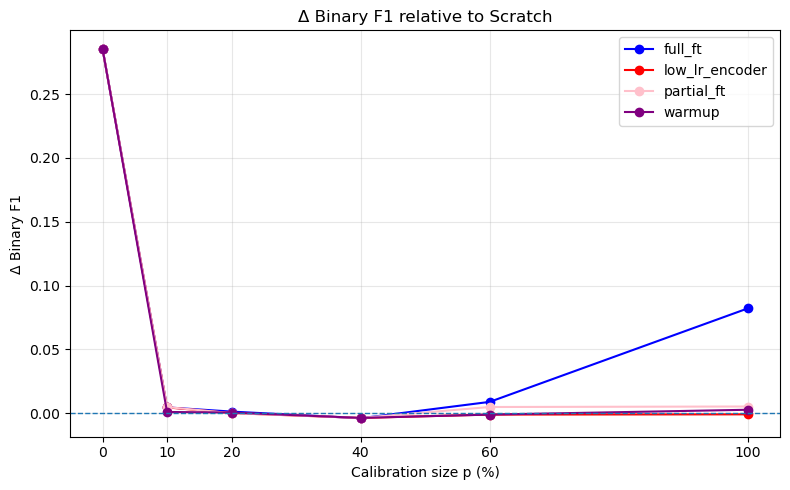

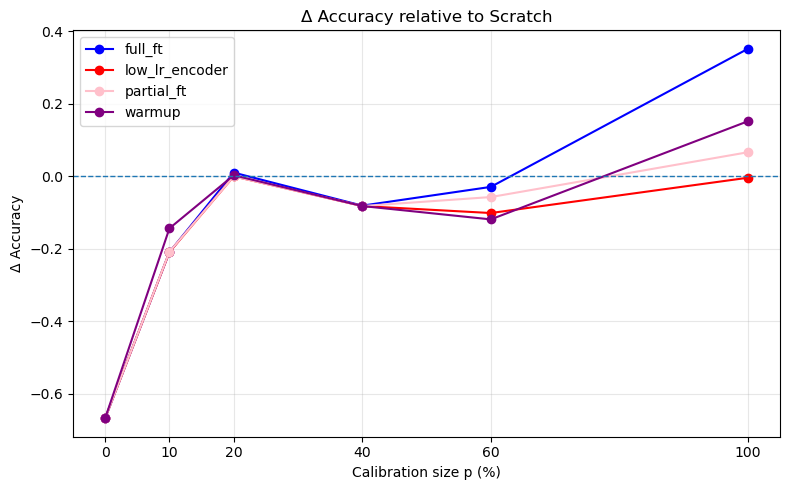

In [32]:
plot_delta_metric("delta_auc", "Δ ROC-AUC")
plot_delta_metric("delta_f1", "Δ Binary F1")
plot_delta_metric("delta_accuracy", "Δ Accuracy")

#### Сохраняем Δ-графики

In [33]:
def save_delta_plot(delta_metric, ylabel, filename):
    plt.figure(figsize=(8, 5))

    p_values = [0, 10, 20, 40, 60, 100]
    strategies = sorted(df_delta["strategy"].unique())

    for strategy in strategies:
        sub = (
            df_delta[df_delta["strategy"] == strategy]
            .groupby("p")[delta_metric]
            .agg(["mean", "std"])
            .reset_index()
            .set_index("p")
            .loc[p_values]
            .reset_index()
        )

        x = sub["p"]
        y = sub["mean"]
        yerr = sub["std"]

        plt.plot(x, y, marker="o", label=strategy, color=COLORS[strategy])
        plt.fill_between(x, y - yerr, y + yerr, alpha=0.15, color=COLORS[strategy])

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks(p_values)
    plt.xlabel("Calibration size p (%)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} relative to Scratch")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300)
    plt.close()

In [34]:
save_delta_plot("delta_auc", "Δ ROC-AUC", "delta_auc_vs_p.png")
save_delta_plot("delta_f1", "Δ Binary F1", "delta_f1_vs_p.png")
save_delta_plot("delta_accuracy", "Δ Accuracy", "delta_accuracy_vs_p.png")